# PaySim Fraud Detection Notebook

Notebook này là bản **độc lập hoàn toàn** cho phần khai phá dữ liệu, tiền xử lý và huấn luyện mô hình bằng **PySpark**.
Nó không import từ các file `.py` trong project để phù hợp với kiểu trình bày notebook trong học phần.

Mục tiêu bám sát đề tài:
- đọc và khám phá full dataset `PaySim` bằng Spark
- làm sạch và chuẩn hóa dữ liệu (null, kiểu dữ liệu, chuỗi, encoding biến phân loại)
- tạo feature phục vụ phát hiện gian lận
- chia tập `train / validation / test`
- huấn luyện và so sánh **Random Forest** và **Gradient Boosted Trees**
- đánh giá bằng `accuracy`, `precision`, `recall`, `F1`, `AUC`
- trực quan hóa **confusion matrix** và **ROC curve** cho từng mô hình

Lưu ý kỹ thuật:
- toàn bộ xử lý nặng dùng Spark, không dùng Pandas cho DataFrame lớn
- notebook đọc full CSV bằng Spark; chỉ các bảng tổng hợp nhỏ mới được `collect()` để vẽ biểu đồ
- để PySpark local ổn định trên Windows, nên dùng **JDK 17** thay vì Java 21

In [9]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
from pyspark.ml import Pipeline
from pyspark.ml.classification import GBTClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import SparkSession, functions as F

if Path('/opt/spark/work').exists():
    REPO_ROOT = Path('/opt/spark/work')
else:
    REPO_ROOT = Path.cwd().resolve()
    if REPO_ROOT.name == 'notebooks':
        REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / 'data' / 'paysim_transactions.csv'
BLACKLIST_PATH = REPO_ROOT / 'data' / 'blacklist_accounts.txt'

TRAINING_MODE = 'interactive'  # 'interactive' or 'full'
TRAIN_SAMPLE_FRACTION = 0.05 if TRAINING_MODE == 'interactive' else 1.0
MAX_ROC_POINTS = 200
MAX_ROC_SAMPLE_ROWS = 5000
RANDOM_SEED = 42

TRANSACTION_TYPES = ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
NUMERIC_FEATURES = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balance_diff_orig',
    'balance_diff_dest',
    'amount_ratio',
    'is_zero_balance_orig',
    'is_large_amount',
]
FEATURE_COLUMNS = NUMERIC_FEATURES + ['type_index']

if TRAINING_MODE == 'full':
    RF_PARAMS = {'numTrees': 80, 'maxDepth': 10}
    GBT_PARAMS = {'maxIter': 30, 'maxDepth': 8}
else:
    RF_PARAMS = {'numTrees': 20, 'maxDepth': 6}
    GBT_PARAMS = {'maxIter': 8, 'maxDepth': 4}

BLACKLIST_ACCOUNTS = []
if BLACKLIST_PATH.exists():
    with BLACKLIST_PATH.open('r', encoding='utf-8') as file_obj:
        for raw_line in file_obj:
            account = raw_line.strip()
            if account and not account.startswith('#'):
                BLACKLIST_ACCOUNTS.append(account.upper())

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('PaySim-EDA-Preprocessing-Training')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.driver.memory', '8g')
    .config('spark.executor.memory', '8g')
    .config('spark.driver.maxResultSize', '2g')
    .config('spark.sql.shuffle.partitions', '16')
    .config('spark.default.parallelism', '8')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

print(f'Repo root: {REPO_ROOT}')
print(f'Dataset path: {DATA_PATH}')
print(f'Blacklist accounts loaded: {len(BLACKLIST_ACCOUNTS)}')
print(f'Training mode: {TRAINING_MODE}')
print(f'Training sample fraction: {TRAIN_SAMPLE_FRACTION:.2f}')


Repo root: D:\Ki2Nam4\BigData\Brainstorm\fraud-detection-pipeline
Dataset path: D:\Ki2Nam4\BigData\Brainstorm\fraud-detection-pipeline\data\paysim_transactions.csv
Blacklist accounts loaded: 2
Training mode: interactive
Training sample fraction: 0.05


## 1. Load the full PaySim dataset with Spark

Bước này đọc **toàn bộ** CSV bằng Spark để giữ đúng tinh thần xử lý phân tán của đề bài.

In [10]:
raw_df = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True).cache()
raw_count = raw_df.count()

print(f'Raw rows: {raw_count:,}')
raw_df.printSchema()
raw_df.show(5, truncate=False)

Raw rows: 6,362,620
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|type    |amount  |nameOrig   |oldbalanceOrg|newbalanceOrig|nameDest   |oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|1   |PAYMENT |9839.64 |C1231006815|170136.0     |160296.36     |M1979787155|0.0           |0.0           |0      |0    

## 2. Data quality profile

Khối này kiểm tra định dạng dữ liệu gốc trước khi làm sạch: null, chuỗi rỗng, phân bố nhãn, phân bố loại giao dịch.

In [11]:
quality_columns = [
    'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg',
    'newbalanceOrig', 'nameDest', 'oldbalanceDest',
    'newbalanceDest', 'isFraud', 'isFlaggedFraud'
]

null_exprs = [
    F.sum(F.when(F.col(column_name).isNull(), 1).otherwise(0)).alias(column_name)
    for column_name in quality_columns
]
blank_exprs = [
    F.sum(F.when(F.trim(F.coalesce(F.col(column_name), F.lit(''))) == '', 1).otherwise(0)).alias(column_name)
    for column_name in ['type', 'nameOrig', 'nameDest']
]

print('Null counts per column:')
raw_df.select(*null_exprs).show(truncate=False)

print('Blank-string counts for string columns:')
raw_df.select(*blank_exprs).show(truncate=False)

fraud_rate = raw_df.agg((F.avg(F.col('isFraud').cast('double')) * 100).alias('fraud_rate_percent')).collect()[0]['fraud_rate_percent']
print(f'Fraud rate: {fraud_rate:.4f}%')

print('Transaction counts by type:')
raw_df.groupBy('type').count().orderBy('type').show(truncate=False)

print('Fraud counts by type:')
raw_df.groupBy('type').agg(
    F.sum('isFraud').alias('fraud_count'),
    F.avg('amount').alias('avg_amount')
).orderBy('type').show(truncate=False)

amount_quantiles = raw_df.approxQuantile('amount', [0.5, 0.9, 0.99, 0.999], 0.01)
print('Amount quantiles (approx):')
print({
    'p50': amount_quantiles[0],
    'p90': amount_quantiles[1],
    'p99': amount_quantiles[2],
    'p99.9': amount_quantiles[3],
})

Null counts per column:
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|0   |0   |0     |0       |0            |0             |0       |0             |0             |0      |0             |
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+

Blank-string counts for string columns:
+----+--------+--------+
|type|nameOrig|nameDest|
+----+--------+--------+
|0   |0       |0       |
+----+--------+--------+

Fraud rate: 0.1291%
Transaction counts by type:
+--------+-------+
|type    |count  |
+--------+-------+
|CASH_IN |1399284|
|CASH_OUT|2237500|
|DEBIT   |41432  |
|PAYMENT |2151495|
|TRANSFER|532909 |
+--------+----

## 3. Small visual summaries

Chỉ các bảng tổng hợp nhỏ mới được đưa về Python để vẽ. Không có `.toPandas()` trên DataFrame lớn.

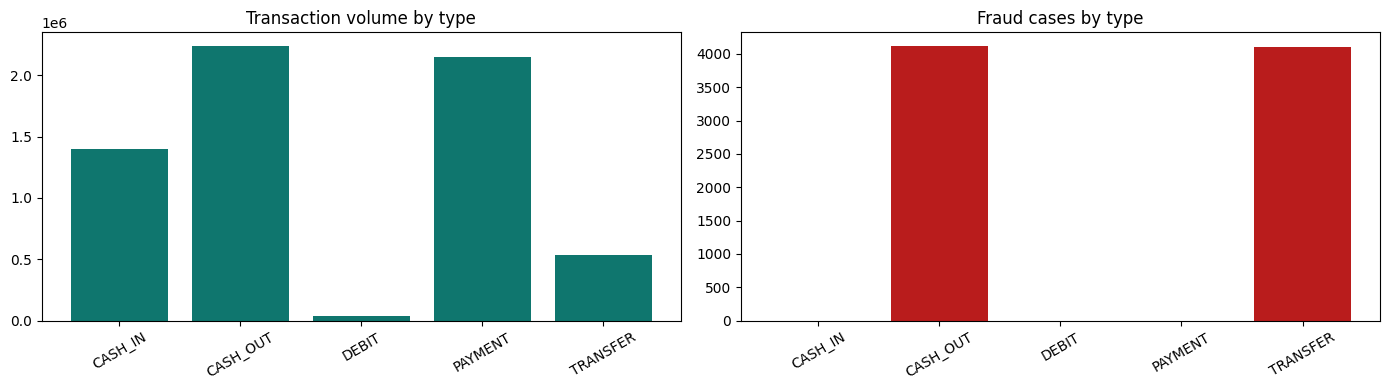

Blacklist-transfer profile:
+---------------------+---------+-----------+------------------+
|is_blacklist_transfer|row_count|fraud_count|avg_amount        |
+---------------------+---------+-----------+------------------+
|0                    |6362604  |8212       |179859.95724299652|
|1                    |16       |1          |953835.353125     |
+---------------------+---------+-----------+------------------+



In [12]:
type_counts = raw_df.groupBy('type').count().orderBy('type').collect()
fraud_counts = raw_df.groupBy('type').agg(F.sum('isFraud').alias('fraud_count')).orderBy('type').collect()

labels = [row['type'] for row in type_counts]
counts = [row['count'] for row in type_counts]
frauds = [row['fraud_count'] for row in fraud_counts]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(labels, counts, color='#0F766E')
axes[0].set_title('Transaction volume by type')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(labels, frauds, color='#B91C1C')
axes[1].set_title('Fraud cases by type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

if BLACKLIST_ACCOUNTS:
    blacklist_summary = (
        raw_df
        .withColumn('type_norm', F.upper(F.trim(F.col('type'))))
        .withColumn(
            'is_blacklist_transfer',
            F.when(
                (F.upper(F.trim(F.col('nameDest'))).isin(BLACKLIST_ACCOUNTS))
                & (F.col('type_norm') == 'TRANSFER'),
                1
            ).otherwise(0)
        )
        .groupBy('is_blacklist_transfer')
        .agg(
            F.count('*').alias('row_count'),
            F.sum('isFraud').alias('fraud_count'),
            F.avg('amount').alias('avg_amount')
        )
        .orderBy('is_blacklist_transfer')
    )
    print('Blacklist-transfer profile:')
    blacklist_summary.show(truncate=False)
else:
    print('No blacklist file found; blacklist profile skipped.')

## 4. Self-contained preprocessing helpers

Khối này viết trực tiếp trong notebook toàn bộ logic làm sạch và tạo đặc trưng, không import từ source code của project.

In [13]:
def clean_paysim_dataframe(df):
    critical_columns = [
        'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg',
        'newbalanceOrig', 'nameDest', 'oldbalanceDest',
        'newbalanceDest', 'isFraud'
    ]

    result = df
    result = result.withColumn('step', F.col('step').cast('integer'))
    result = result.withColumn('isFraud', F.col('isFraud').cast('double'))
    result = result.withColumn('isFlaggedFraud', F.coalesce(F.col('isFlaggedFraud').cast('integer'), F.lit(0)))

    for column_name in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
        result = result.withColumn(column_name, F.col(column_name).cast('double'))

    result = result.withColumn(
        'type',
        F.upper(F.regexp_replace(F.trim(F.coalesce(F.col('type'), F.lit(''))), r'\s+', '_'))
    )
    result = result.withColumn('nameOrig', F.upper(F.trim(F.coalesce(F.col('nameOrig'), F.lit('')))))
    result = result.withColumn('nameDest', F.upper(F.trim(F.coalesce(F.col('nameDest'), F.lit('')))))

    result = result.dropna(subset=critical_columns)
    result = result.filter(F.length(F.col('type')) > 0)
    result = result.filter(F.length(F.col('nameOrig')) > 0)
    result = result.filter(F.length(F.col('nameDest')) > 0)
    result = result.filter(F.col('type').isin(TRANSACTION_TYPES))

    return result


def add_domain_features(df):
    result = df
    result = result.withColumn('balance_diff_orig', F.col('oldbalanceOrg') - F.col('newbalanceOrig'))
    result = result.withColumn('balance_diff_dest', F.col('newbalanceDest') - F.col('oldbalanceDest'))
    result = result.withColumn('amount_ratio', F.col('amount') / (F.col('oldbalanceOrg') + F.lit(1.0)))
    result = result.withColumn('is_zero_balance_orig', F.when(F.col('newbalanceOrig') == 0.0, 1.0).otherwise(0.0))
    result = result.withColumn('is_large_amount', F.when(F.col('amount') > 200000.0, 1.0).otherwise(0.0))
    return result


def prepare_modeling_dataframe(df):
    cleaned = clean_paysim_dataframe(df)
    enriched = add_domain_features(cleaned)
    return enriched.withColumnRenamed('isFraud', 'label')


def sample_by_label(df, fraction, seed):
    if fraction >= 1.0:
        return df
    return df.sampleBy('label', fractions={0.0: fraction, 1.0: fraction}, seed=seed)


def add_class_weights(train_df):
    total = train_df.count()
    fraud_count = train_df.filter(F.col('label') == 1.0).count()
    non_fraud_count = total - fraud_count
    weight_fraud = total / (2.0 * fraud_count) if fraud_count else 1.0
    weight_non_fraud = total / (2.0 * non_fraud_count)
    weighted = train_df.withColumn(
        'weight',
        F.when(F.col('label') == 1.0, F.lit(weight_fraud)).otherwise(F.lit(weight_non_fraud))
    )
    return weighted, {
        'total': total,
        'fraud_count': fraud_count,
        'non_fraud_count': non_fraud_count,
        'weight_fraud': weight_fraud,
        'weight_non_fraud': weight_non_fraud,
    }


def build_pipeline(classifier):
    type_indexer = StringIndexer(inputCol='type', outputCol='type_index', handleInvalid='keep')
    assembler = VectorAssembler(inputCols=FEATURE_COLUMNS, outputCol='raw_features', handleInvalid='keep')
    scaler = StandardScaler(inputCol='raw_features', outputCol='features', withStd=True, withMean=False)
    return Pipeline(stages=[type_indexer, assembler, scaler, classifier])


def evaluate_predictions(predictions):
    evaluators = {
        'accuracy': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy'),
        'precision': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision'),
        'recall': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall'),
        'f1': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1'),
        'auc': BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'),
    }
    return {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}


def confusion_matrix_counts(predictions):
    counts = {
        (int(row['label']), int(row['prediction'])): int(row['count'])
        for row in predictions.groupBy('label', 'prediction').count().collect()
    }
    return {
        'tn': counts.get((0, 0), 0),
        'fp': counts.get((0, 1), 0),
        'fn': counts.get((1, 0), 0),
        'tp': counts.get((1, 1), 0),
    }


def roc_curve_points(predictions, max_points=MAX_ROC_POINTS, max_sample_rows=MAX_ROC_SAMPLE_ROWS):
    scored_rows = (
        predictions
        .select(
            vector_to_array('probability')[1].alias('score'),
            F.col('label').cast('double').alias('label')
        )
        .limit(max_sample_rows)
        .collect()
    )

    scored_pairs = [
        (float(row['score']), float(row['label']))
        for row in scored_rows
    ]
    scored_pairs.sort(key=lambda item: item[0], reverse=True)

    positives = sum(1 for _, label in scored_pairs if label == 1.0)
    negatives = len(scored_pairs) - positives

    if positives == 0 or negatives == 0:
        return [
            {'fpr': 0.0, 'tpr': 0.0},
            {'fpr': 1.0, 'tpr': 1.0},
        ]

    points = [{'fpr': 0.0, 'tpr': 0.0}]
    tp = 0
    fp = 0

    for _, label in scored_pairs:
        if label == 1.0:
            tp += 1
        else:
            fp += 1
        points.append({
            'fpr': fp / negatives,
            'tpr': tp / positives,
        })

    if len(points) <= max_points:
        return points

    step = max(1, len(points) // (max_points - 1))
    sampled = points[::step]
    if sampled[-1] != points[-1]:
        sampled.append(points[-1])
    return sampled


def train_and_evaluate_model(model_name, classifier, train_weighted_df, validation_df, test_df):
    print(f'\nTraining {model_name}...')
    started_at = time.time()
    pipeline = build_pipeline(classifier)
    model = pipeline.fit(train_weighted_df)
    training_time = time.time() - started_at

    validation_predictions = model.transform(validation_df).cache()
    test_predictions = model.transform(test_df).cache()

    validation_metrics = evaluate_predictions(validation_predictions)
    test_metrics = evaluate_predictions(test_predictions)
    matrix = confusion_matrix_counts(test_predictions)
    try:
        roc_points = roc_curve_points(test_predictions)
    except Exception as exc:
        print(f'  [WARN] ROC plotting points skipped: {exc}')
        roc_points = [
            {'fpr': 0.0, 'tpr': 0.0},
            {'fpr': 1.0, 'tpr': 1.0},
        ]

    validation_predictions.unpersist()
    test_predictions.unpersist()

    print(f'  Training time: {training_time:.1f}s')
    print(f"  Validation AUC: {validation_metrics['auc']:.6f}")
    print(f"  Test AUC:       {test_metrics['auc']:.6f}")

    return {
        'model_name': model_name,
        'training_time_seconds': training_time,
        'validation_metrics': validation_metrics,
        'test_metrics': test_metrics,
        'confusion_matrix': matrix,
        'roc_points': roc_points,
    }

## 5. Apply preprocessing on the full dataset

Bước này thực sự chạy cleaning và feature engineering trên full Spark DataFrame.

In [14]:
clean_df = clean_paysim_dataframe(raw_df).cache()
clean_count = clean_df.count()
dropped_count = raw_count - clean_count

prepared_df = prepare_modeling_dataframe(raw_df).cache()
prepared_count = prepared_df.count()

print(f'Clean rows: {clean_count:,}')
print(f'Dropped rows: {dropped_count:,}')
print(f'Prepared rows: {prepared_count:,}')

print('Prepared schema:')
prepared_df.printSchema()

prepared_df.select(
    'type', 'amount', 'balance_diff_orig', 'balance_diff_dest',
    'amount_ratio', 'is_zero_balance_orig', 'is_large_amount', 'label'
).show(5, truncate=False)

Clean rows: 6,362,620
Dropped rows: 0
Prepared rows: 6,362,620
Prepared schema:
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = false)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = false)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = false)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- label: double (nullable = true)
 |-- isFlaggedFraud: integer (nullable = false)
 |-- balance_diff_orig: double (nullable = true)
 |-- balance_diff_dest: double (nullable = true)
 |-- amount_ratio: double (nullable = true)
 |-- is_zero_balance_orig: double (nullable = false)
 |-- is_large_amount: double (nullable = false)

+--------+--------+------------------+-----------------+--------------------+--------------------+---------------+-----+
|type    |amount  |balance_diff_orig |balance_diff_dest|amount_ratio        |is_zero_bal

## 6. Train / validation / test split

Theo lưu ý của giảng viên, notebook tách rõ `train`, `validation`, `test` và chuẩn bị trọng số để xử lý dữ liệu mất cân bằng.

In [15]:
train_df, validation_df, test_df = prepared_df.randomSplit([0.7, 0.15, 0.15], seed=RANDOM_SEED)

print('Initial split summary:')
print(f'  Train:      {train_df.count():,}')
print(f'  Validation: {validation_df.count():,}')
print(f'  Test:       {test_df.count():,}')

train_df = sample_by_label(train_df, TRAIN_SAMPLE_FRACTION, RANDOM_SEED).cache()
validation_df = sample_by_label(validation_df, TRAIN_SAMPLE_FRACTION, RANDOM_SEED + 1).cache()
test_df = sample_by_label(test_df, TRAIN_SAMPLE_FRACTION, RANDOM_SEED + 2).cache()

print('Effective split summary used for model fitting:')
print(f'  Train:      {train_df.count():,}')
print(f'  Validation: {validation_df.count():,}')
print(f'  Test:       {test_df.count():,}')

train_weighted_df, class_summary = add_class_weights(train_df)
print('Class summary on training split:')
for key, value in class_summary.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.6f}')
    else:
        print(f'  {key}: {value:,}')

Initial split summary:
  Train:      4,454,190
  Validation: 953,556
  Test:       954,874
Effective split summary used for model fitting:
  Train:      222,052
  Validation: 47,603
  Test:       47,587
Class summary on training split:
  total: 222,052
  fraud_count: 281
  non_fraud_count: 221,771
  weight_fraud: 395.110320
  weight_non_fraud: 0.500634


## 7. Train candidate models

Notebook huấn luyện 2 mô hình đúng yêu cầu đề tài: **Random Forest** và **Gradient Boosted Trees**.

In [16]:
candidate_models = {
    'rf': (
        'RandomForest',
        RandomForestClassifier(
            featuresCol='features',
            labelCol='label',
            weightCol='weight',
            numTrees=RF_PARAMS['numTrees'],
            maxDepth=RF_PARAMS['maxDepth'],
            seed=RANDOM_SEED,
        ),
    ),
    'gbt': (
        'GradientBoostedTrees',
        GBTClassifier(
            featuresCol='features',
            labelCol='label',
            weightCol='weight',
            maxIter=GBT_PARAMS['maxIter'],
            maxDepth=GBT_PARAMS['maxDepth'],
            seed=RANDOM_SEED,
        ),
    ),
}

training_results = {}
for model_key, (model_name, classifier) in candidate_models.items():
    training_results[model_key] = train_and_evaluate_model(
        model_name=model_name,
        classifier=classifier,
        train_weighted_df=train_weighted_df,
        validation_df=validation_df,
        test_df=test_df,
    )

metrics_rows = []
for model_key, result in training_results.items():
    metrics_rows.append({
        'model_key': model_key,
        'model_name': result['model_name'],
        'validation_accuracy': result['validation_metrics']['accuracy'],
        'validation_precision': result['validation_metrics']['precision'],
        'validation_recall': result['validation_metrics']['recall'],
        'validation_f1': result['validation_metrics']['f1'],
        'validation_auc': result['validation_metrics']['auc'],
        'test_accuracy': result['test_metrics']['accuracy'],
        'test_precision': result['test_metrics']['precision'],
        'test_recall': result['test_metrics']['recall'],
        'test_f1': result['test_metrics']['f1'],
        'test_auc': result['test_metrics']['auc'],
        'training_time_seconds': result['training_time_seconds'],
    })

best_model_key = max(metrics_rows, key=lambda row: row['validation_auc'])['model_key']
best_model_name = training_results[best_model_key]['model_name']

print(f'Candidate models trained: {len(metrics_rows)}')
for row in metrics_rows:
    print(row)

print(f'Best model by validation AUC: {best_model_name} ({best_model_key})')


Training RandomForest...
  Training time: 3.6s
  Validation AUC: 1.000000
  Test AUC:       1.000000

Training GradientBoostedTrees...
  Training time: 6.0s
  Validation AUC: 0.999996
  Test AUC:       1.000000
Candidate models trained: 2
{'model_key': 'rf', 'model_name': 'RandomForest', 'validation_accuracy': 0.9999789929206142, 'validation_precision': 0.9999793892806027, 'validation_recall': 0.9999789929206142, 'validation_f1': 0.9999790928438795, 'validation_auc': 0.9999995955759241, 'test_accuracy': 1.0, 'test_precision': 1.0, 'test_recall': 1.0, 'test_f1': 1.0, 'test_auc': 0.9999999999999999, 'training_time_seconds': 3.572299003601074}
{'model_key': 'gbt', 'model_name': 'GradientBoostedTrees', 'validation_accuracy': 0.9998109362855282, 'validation_precision': 0.9998388309319257, 'validation_recall': 0.9998109362855282, 'validation_f1': 0.9998184564246118, 'validation_auc': 0.9999963601833173, 'test_accuracy': 0.9998108727173388, 'test_precision': 0.9998332693692328, 'test_recall'

## 8. Compare AUC across models

Biểu đồ này so sánh AUC trên validation và test cho từng mô hình.

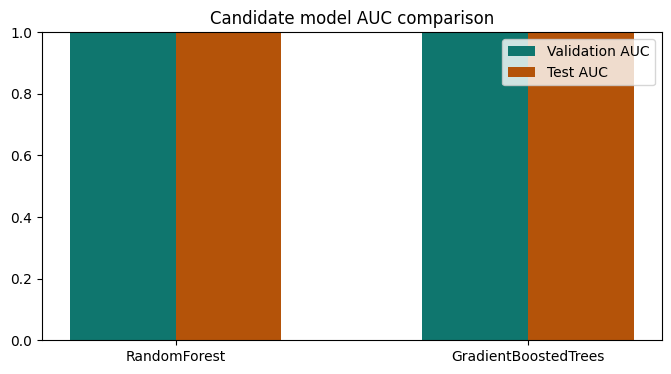

In [17]:
model_names = [row['model_name'] for row in metrics_rows]
validation_auc = [row['validation_auc'] for row in metrics_rows]
test_auc = [row['test_auc'] for row in metrics_rows]

x_positions = list(range(len(model_names)))

plt.figure(figsize=(8, 4))
plt.bar([value - 0.15 for value in x_positions], validation_auc, width=0.3, label='Validation AUC', color='#0F766E')
plt.bar([value + 0.15 for value in x_positions], test_auc, width=0.3, label='Test AUC', color='#B45309')
plt.xticks(x_positions, model_names)
plt.ylim(0.0, 1.0)
plt.title('Candidate model AUC comparison')
plt.legend()
plt.show()

## 9. Confusion matrix per model (test split)

Mỗi confusion matrix bên dưới dùng đúng tập test của notebook.

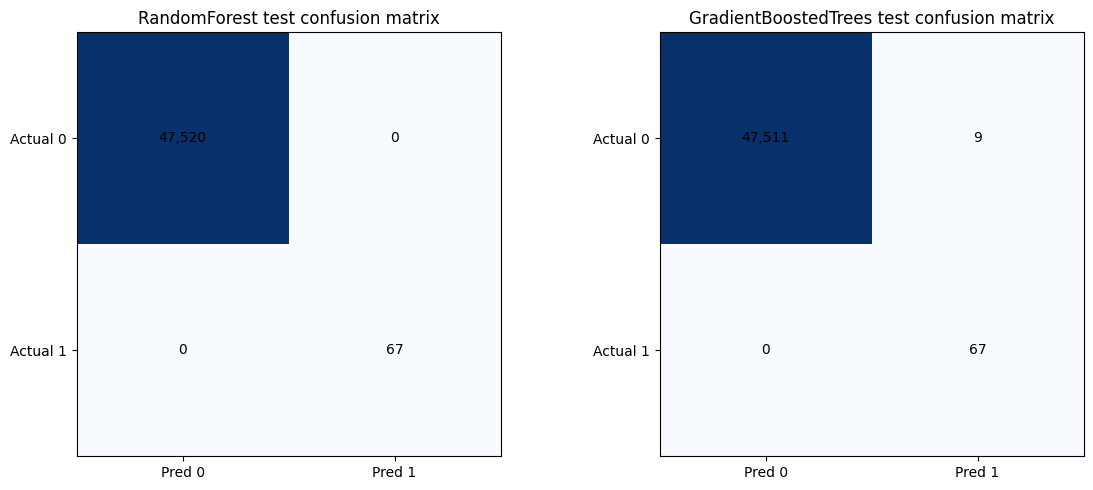

In [18]:
fig, axes = plt.subplots(1, len(metrics_rows), figsize=(6 * len(metrics_rows), 5))
if len(metrics_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, metrics_rows):
    matrix = training_results[row['model_key']]['confusion_matrix']
    values = [
        [matrix['tn'], matrix['fp']],
        [matrix['fn'], matrix['tp']],
    ]
    ax.imshow(values, cmap='Blues')
    ax.set_title(f"{row['model_name']} test confusion matrix")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Actual 0', 'Actual 1'])
    for row_index, row_values in enumerate(values):
        for col_index, value in enumerate(row_values):
            ax.text(col_index, row_index, f'{value:,}', ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 10. ROC curve per model (test split)

Mỗi ROC curve được tính từ Spark predictions rồi chỉ thu một lượng nhỏ điểm xuống Python để vẽ.

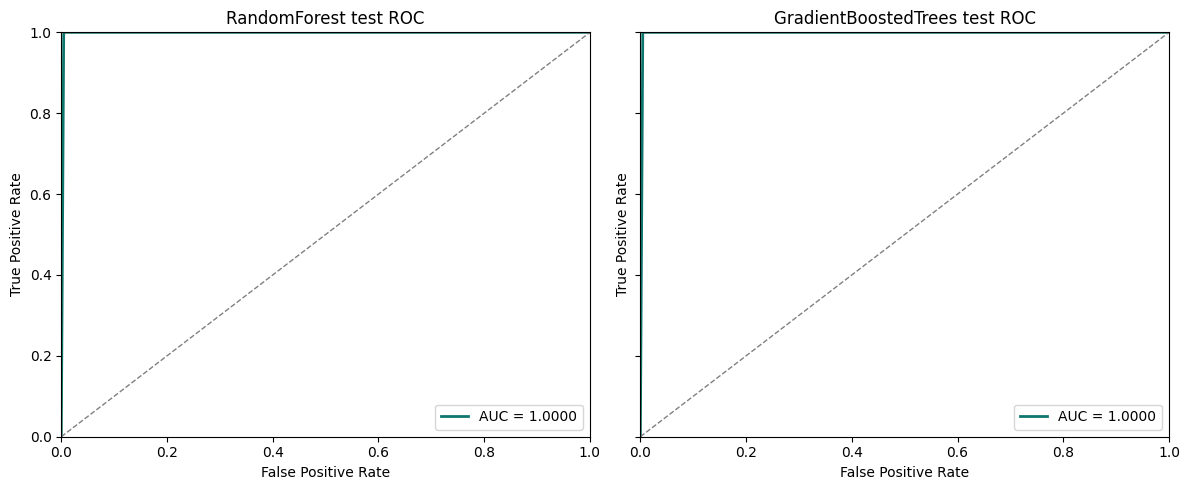

In [19]:
fig, axes = plt.subplots(1, len(metrics_rows), figsize=(6 * len(metrics_rows), 5), sharex=True, sharey=True)
if len(metrics_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, metrics_rows):
    roc_points = training_results[row['model_key']]['roc_points']
    fpr = [point['fpr'] for point in roc_points]
    tpr = [point['tpr'] for point in roc_points]
    ax.plot(fpr, tpr, color='#0F766E', linewidth=2, label=f"AUC = {row['test_auc']:.4f}")
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_title(f"{row['model_name']} test ROC")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 11. Conclusions

Notebook này hoàn thành các yêu cầu chính của phần dữ liệu và mô hình trong đề bài:
- khám phá dữ liệu đầy đủ trên `PaySim`
- làm sạch và chuẩn hóa dữ liệu bằng Spark
- tạo đặc trưng phục vụ phát hiện gian lận
- chia `train / validation / test` rõ ràng
- huấn luyện và đánh giá 2 mô hình AI
- báo cáo `accuracy`, `precision`, `recall`, `F1`, `AUC`
- trực quan hóa confusion matrix và ROC curve

Gợi ý sử dụng:
- `TRAINING_MODE='interactive'`: phù hợp khi chạy notebook local
- `TRAINING_MODE='full'`: dùng khi Spark local đủ khỏe hoặc chạy trong môi trường Docker / cluster ổn định


In [20]:
# Optional cleanup when you are done with the notebook.
# raw_df.unpersist()
# clean_df.unpersist()
# prepared_df.unpersist()
# train_df.unpersist()
# validation_df.unpersist()
# test_df.unpersist()
# spark.stop()